In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [5]:
df=pd.read_csv("StudentsPerformance.csv")

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.shape

(1000, 8)

In [9]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
df[]

gender                         femalefemalefemalemalemalefemalefemalemalemale...
race/ethnicity                 group Bgroup Cgroup Bgroup Agroup Cgroup Bgrou...
parental level of education    bachelor's degreesome collegemaster's degreeas...
lunch                          standardstandardstandardfree/reducedstandardst...
test preparation course        nonecompletednonenonenonenonecompletednonecomp...
math score                                                                 66089
reading score                                                              69169
writing score                                                              68054
dtype: object

In [16]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [19]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [21]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [22]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [23]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [25]:
df['math score'].describe()

count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64

In [26]:
df['reading score'].describe()

count    1000.000000
mean       69.169000
std        14.600192
min        17.000000
25%        59.000000
50%        70.000000
75%        79.000000
max       100.000000
Name: reading score, dtype: float64

In [27]:
df['writing score'].describe()

count    1000.000000
mean       68.054000
std        15.195657
min        10.000000
25%        57.750000
50%        69.000000
75%        79.000000
max       100.000000
Name: writing score, dtype: float64

In [42]:
np.mean(df['math score'])

np.float64(66.089)

In [43]:
np.mean(df['reading score'])

np.float64(69.169)

In [44]:
np.mean(df['writing score'])

np.float64(68.054)

In [47]:
average_score=(df['math score']+df['reading score']+df['writing score'])/3

In [49]:
df['Average']=average_score

In [50]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [54]:
df['Target']=(df['Average']>=50).astype(int)

In [55]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average,Target
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0
4,male,group C,some college,standard,none,76,78,75,76.333333,1


In [57]:
df['Target'].value_counts()

Target
1    897
0    103
Name: count, dtype: int64

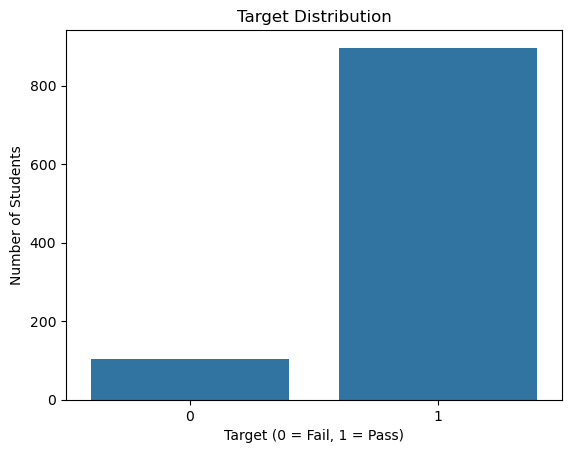

In [75]:
sns.countplot(x='Target', data=df)
plt.title('Target Distribution')
plt.xlabel('Target (0 = Fail, 1 = Pass)')
plt.ylabel('Number of Students')
plt.show()

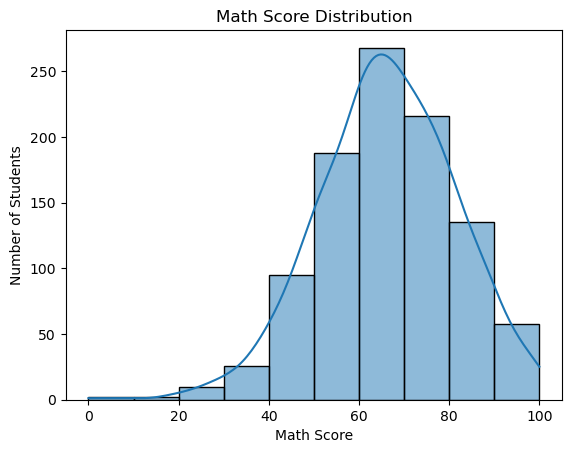

In [79]:
sns.histplot(df['math score'], bins=10, kde=True)
plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.show()

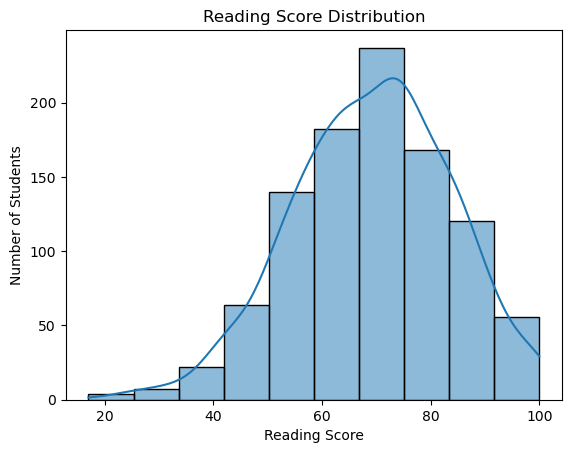

In [80]:
sns.histplot(df['reading score'], bins=10, kde=True)
plt.title('Reading Score Distribution')
plt.xlabel('Reading Score')
plt.ylabel('Number of Students')
plt.show()

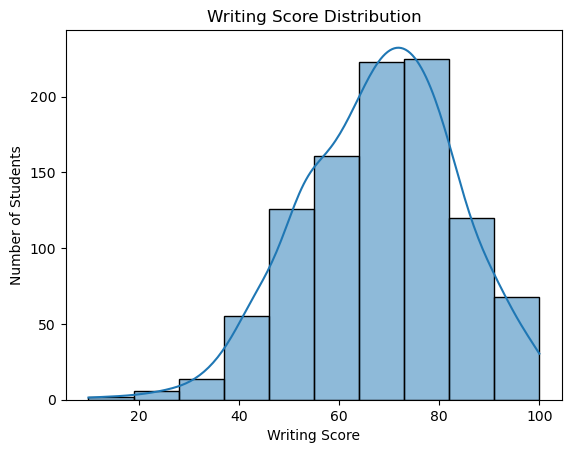

In [81]:
sns.histplot(df['writing score'], bins=10, kde=True)
plt.title('Writing Score Distribution')
plt.xlabel('Writing Score')
plt.ylabel('Number of Students')
plt.show()

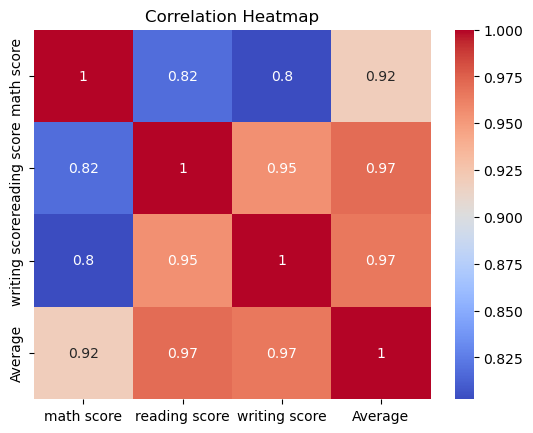

In [83]:
sns.heatmap(
    df[['math score', 'reading score', 'writing score', 'Average']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

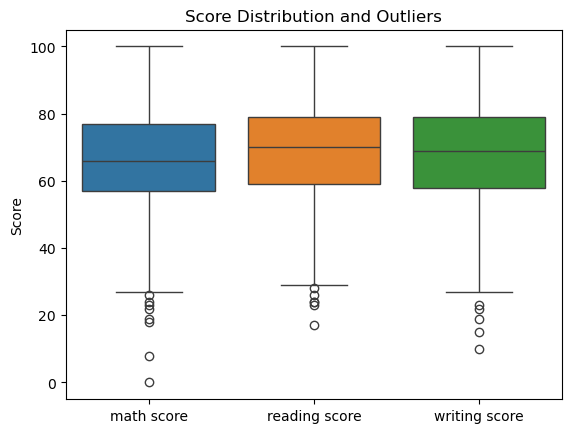

In [84]:
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.title('Score Distribution and Outliers')
plt.ylabel('Score')
plt.show()

In [91]:
X=df.iloc[:,0:8]
y=df['Target']

In [92]:
X

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [93]:
y

0      1
1      1
2      1
3      0
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Target, Length: 1000, dtype: int64

In [94]:
X.shape

(1000, 8)

In [89]:
y.shape

(1000,)

In [90]:
X.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Average'],
      dtype='object')

In [96]:
label_encoder=LabelEncoder()

In [101]:
X['gender']=label_encoder.fit_transform(X['gender'])

In [103]:
X['lunch']=label_encoder.fit_transform(X['lunch'])

In [104]:
X = pd.get_dummies(
    X,
    columns=['race/ethnicity',
             'parental level of education',
             'test preparation course'],
    drop_first=True
)

In [105]:
X.head()

,gender,lunch,math score,reading score,writing score,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,test preparation course_none
0,0,1,72,72,74,True,False,False,False,True,False,False,False,False,True
1,0,1,69,90,88,False,True,False,False,False,False,False,True,False,False
2,0,1,90,95,93,True,False,False,False,False,False,True,False,False,True
3,1,0,47,57,44,False,False,False,False,False,False,False,False,False,True
4,1,1,76,78,75,False,True,False,False,False,False,False,True,False,True


In [106]:
X.shape

(1000, 15)

In [107]:
X.dtypes

gender                                           int64
lunch                                            int64
math score                                       int64
reading score                                    int64
writing score                                    int64
race/ethnicity_group B                            bool
race/ethnicity_group C                            bool
race/ethnicity_group D                            bool
race/ethnicity_group E                            bool
parental level of education_bachelor's degree     bool
parental level of education_high school           bool
parental level of education_master's degree       bool
parental level of education_some college          bool
parental level of education_some high school      bool
test preparation course_none                      bool
dtype: object

In [108]:
X = X.astype(int)

In [109]:
X.dtypes

gender                                           int64
lunch                                            int64
math score                                       int64
reading score                                    int64
writing score                                    int64
race/ethnicity_group B                           int64
race/ethnicity_group C                           int64
race/ethnicity_group D                           int64
race/ethnicity_group E                           int64
parental level of education_bachelor's degree    int64
parental level of education_high school          int64
parental level of education_master's degree      int64
parental level of education_some college         int64
parental level of education_some high school     int64
test preparation course_none                     int64
dtype: object

In [111]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [113]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 15)
(200, 15)
(800,)
(200,)


In [115]:
scaler = StandardScaler()

In [123]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
X_train.shape

(800, 15)

In [125]:
X_test.shape

(200, 15)

In [126]:
model = LogisticRegression()

In [128]:
model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [129]:
y_pred=model.predict(X_test)

In [130]:
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [132]:
from sklearn.metrics import accuracy_score

In [133]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.975


In [135]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 23   4]
 [  1 172]]


In [137]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90        27
           1       0.98      0.99      0.99       173

    accuracy                           0.97       200
   macro avg       0.97      0.92      0.94       200
weighted avg       0.97      0.97      0.97       200

